# Analysis of the Relationship Between Product Categories and Sales Effectiveness (Inner)

## Member: Phuong

### Bàn luận:
Dựa trên phần EDA, ta có thể thấy có 5 root mỗi root chứa nhiều middle, mỗi middle chứa nhiều leaf
Vì vậy có rất nhiều thứ cần phải phân tích trong một danh mục.
Để đảm bảo insight được khách quan và thực sự cung cấp thông tin hữu ích cho người đọc. Em sẽ tiếp cận bằng một mục tiêu phân tích bao quát nhất

### Analysis Objectives:
1. **Question 1**: Với từng root danh mục, danh mục con trực tiếp nào đang phát triển mạnh nhất (doanh thu, số danh mục con, tổng sản phẩm)?
2. **Question 2**: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict doanh thu xem cái nào có trọng số cao nhất)?
attributes: trong bảng product
target: price * sold_count


!!! - Chấp nhận rằng linear chỉ cho bạn insight tuyến tính, không phải là “chân lý” nhân quả.

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, FixedLocator
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [23]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (497, 4)
Products: (55883, 14)
Reviews: (158126, 8)


## 2. Category Exploration
- Khám phá các root category (trỏng có bao nhiêu nhánh)
- EDA cơ bản về dữ liệu từng category (doanh thu tổng, chart danh thu cho từng category)
- ...

In [24]:
# preprocess xong thì bỏ
df_category = df_category.copy()
df_category['category_id'] = df_category['category_id'].astype(int)
df_category['category_name'] = df_category['category_name'].astype(str).str.strip()
df_category['parent_category'] = df_category['parent_category'].fillna('').astype(str).str.strip()

In [ ]:
sns.set_theme(style="whitegrid")
main_cmap = sns.color_palette("mako", as_cmap=True)

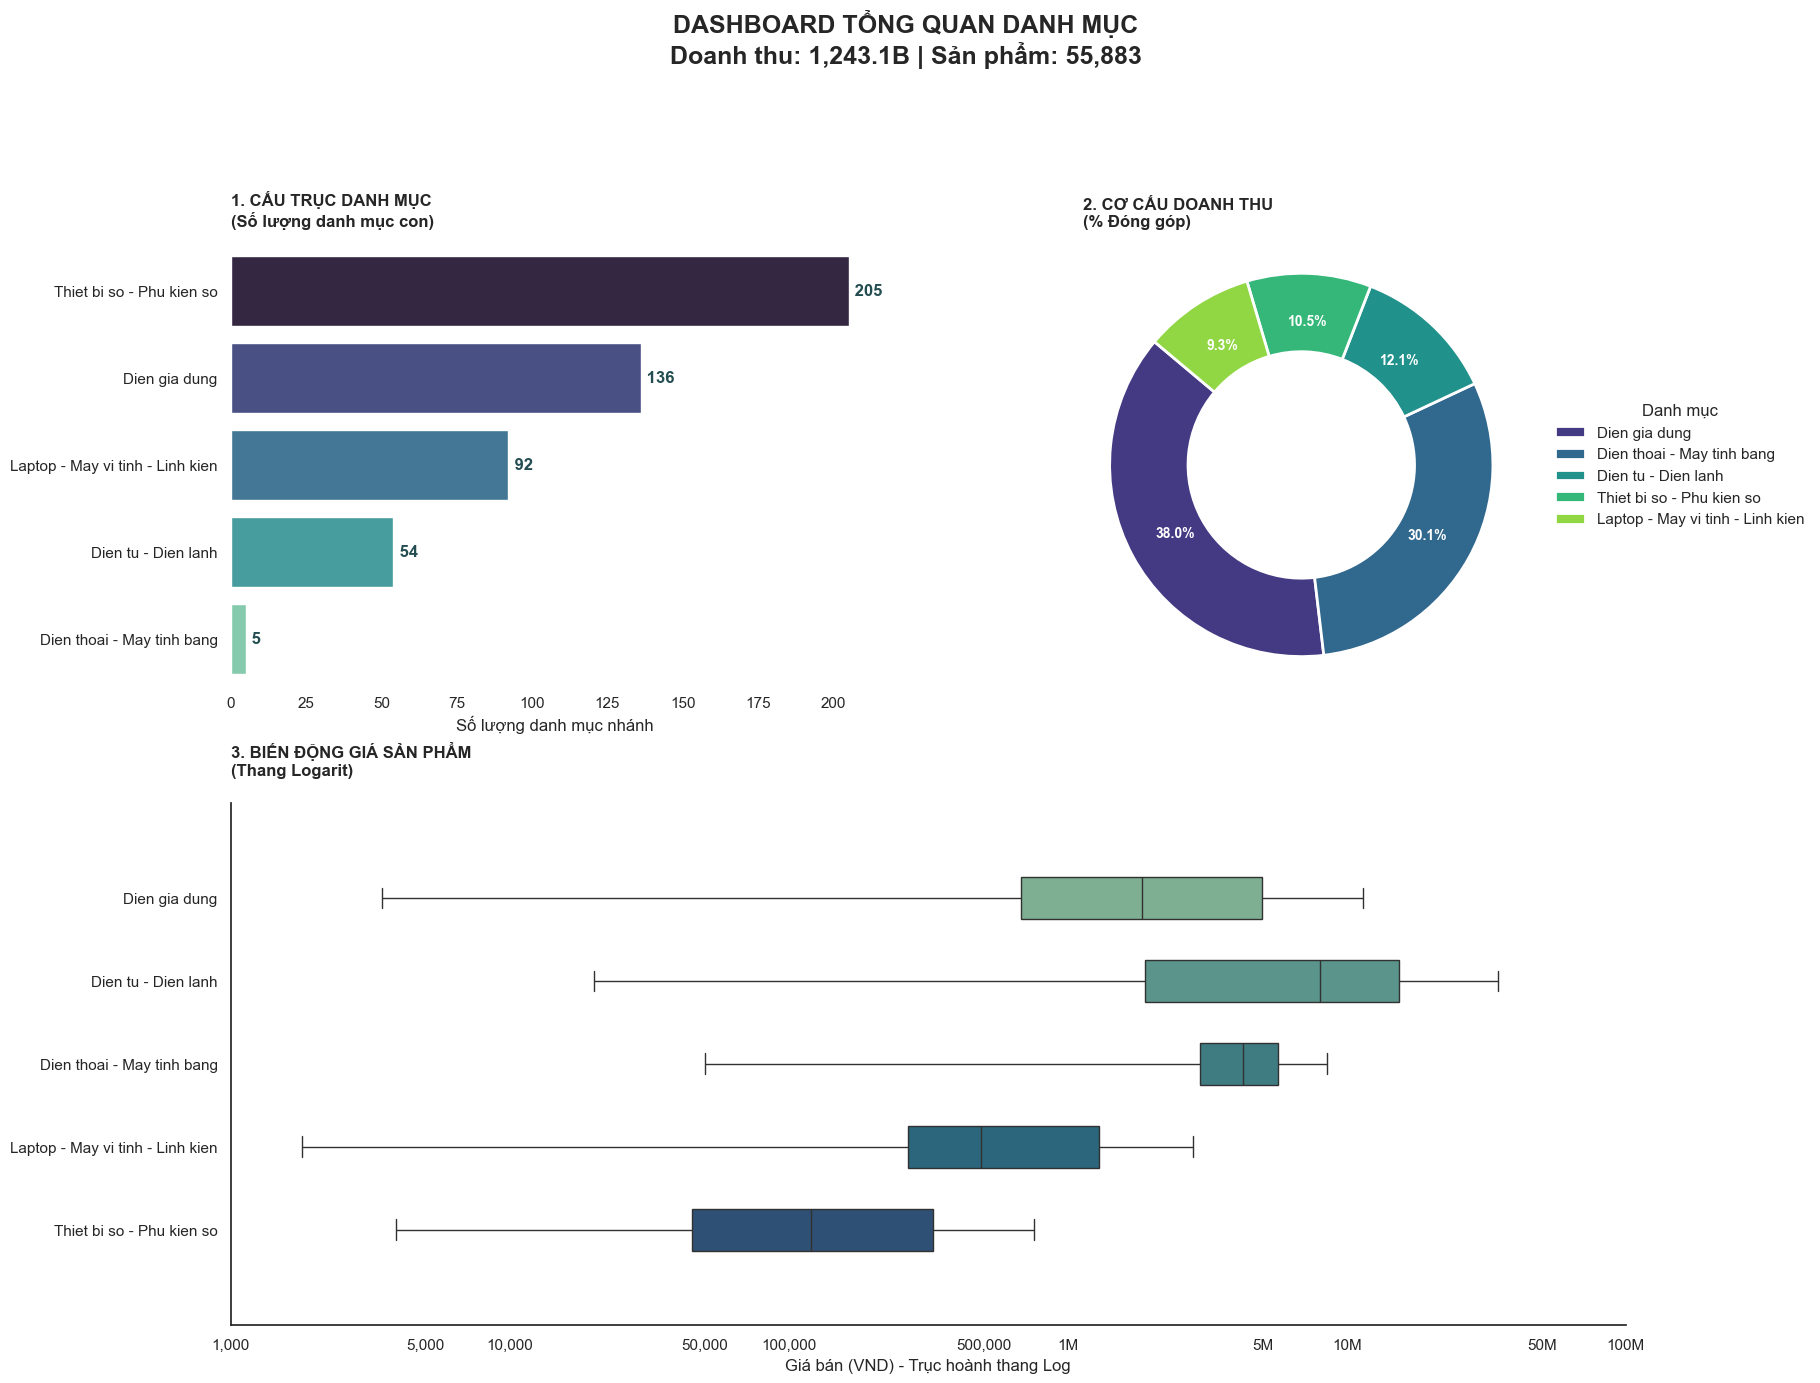

<Figure size 1800x1400 with 0 Axes>

In [ ]:
parent_dict = dict(zip(df_category['category_name'], df_category['parent_category'])) 
root_categories = [
    "Thiet bi so - Phu kien so", 
    "Dien gia dung", 
    "Laptop - May vi tinh - Linh kien", 
    "Dien tu - Dien lanh", 
    "Dien thoai - May tinh bang"
]
for root in root_categories:
    df_category.loc[df_category['category_name'] == root, 'root_category'] = root
cat_to_root_dict = dict(zip(df_category['category_id'], df_category['root_category']))
df_product_eda = df_product.copy()
df_product_eda['category_id'] = df_product_eda['category_id'].astype(str)
df_product_eda['root_category'] = df_product_eda['category_id'].map(cat_to_root_dict)
df_product_eda['price'] = pd.to_numeric(df_product_eda['price'], errors='coerce').fillna(0)
df_product_eda['sold_count'] = pd.to_numeric(df_product_eda['sold_count'], errors='coerce').fillna(0)
df_product_eda['revenue'] = df_product_eda['price'] * df_product_eda['sold_count']

# --- CẤU HÌNH STYLE ĐỒNG NHẤT ---
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="white", palette="crest") # Sử dụng crest xuyên suốt
MAIN_COLOR = "#234d51" # Màu chủ đạo lấy từ palette crest

fig = plt.figure(figsize=(18, 14))
# Tăng chiều cao cho hàng 1 để Donut chart có không gian
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.2],  # boxplot lớn hơn
    width_ratios=[1, 1],     # cân 2 bên
    hspace=0.25,
    wspace=0.15              # thêm khoảng cách ngang
)

def format_money(x, pos):
    if x >= 1_000_000_000: return f'{x / 1_000_000_000:,.1f}B'
    if x >= 1_000_000: return f'{x / 1_000_000:,.0f}M'
    return f'{x:,.0f}'

# --- AX1: BAR CHART (Đồng bộ màu) ---
ax1 = fig.add_subplot(gs[0, 0])
sub_cat_count = df_category[df_category['parent_category'] != ''].groupby('root_category')['category_id'].count().sort_values(ascending=False)
    
sns.barplot(x=sub_cat_count.values, y=sub_cat_count.index, palette="mako", ax=ax1)
ax1.set_title('1. CẤU TRỤC DANH MỤC\n(Số lượng danh mục con)', loc='left', fontweight='bold', pad=15)
ax1.set_xlabel('Số lượng danh mục nhánh')
ax1.set_ylabel('')

for i, v in enumerate(sub_cat_count.values):
    ax1.text(v + 0.5, i, f' {int(v)}', va='center', fontweight='bold', color=MAIN_COLOR)
sns.despine(ax=ax1, left=True, bottom=True)

# --- AX2: DONUT CHART (Phóng to & Cân đối) ---
ax2 = fig.add_subplot(gs[0, 1])
revenue_by_root = df_product_eda.groupby('root_category')['revenue'].sum().sort_values(ascending=False)
revenue_by_root = revenue_by_root[revenue_by_root > 0]

# Tăng size bằng cách điều chỉnh radius
wedges, texts, autotexts = ax2.pie(
    revenue_by_root.values, 
    autopct='%1.1f%%',
    startangle=140, 
    pctdistance=0.75,
    radius=1.1, # Phóng to donut
    colors=sns.color_palette("viridis", len(revenue_by_root)),
    wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 2}
)

ax2.legend(
    wedges, revenue_by_root.index,
    title="Danh mục",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),  # đặt bên phải
    frameon=False
)

plt.setp(autotexts, size=10, weight="bold", color="white")
ax2.set_title(
    '2. CƠ CẤU DOANH THU\n(% Đóng góp)',
    loc='left',
    fontweight='bold',
    pad=15  # giảm pad cho cân
)
# --- AX3: BOXPLOT (Fix Median Log Scale) ---
ax3 = fig.add_subplot(gs[1, :])
top5_roots_by_items = df_product_eda['root_category'].value_counts().head(5).index
df_boxplot = df_product_eda[(df_product_eda['root_category'].isin(top5_roots_by_items)) & (df_product_eda['price'] > 0)]

sns.boxplot(
    data=df_boxplot, x='price', y='root_category',
    palette="crest", showfliers=False, ax=ax3, width=0.5
)

ax3.set_xscale('log')
major_ticks = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8]
ax3.set_xticks(major_ticks)
ax3.xaxis.set_major_formatter(FuncFormatter(format_money))

ax3.margins(y=0.2)
ax3.set_title(
    '3. BIẾN ĐỘNG GIÁ SẢN PHẨM \n(Thang Logarit)',
    loc='left',
    fontweight='bold',
    pad=20
)

ax3.set_xlabel('Giá bán (VND) - Trục hoành thang Log')
ax3.set_ylabel('')
sns.despine(ax=ax3)

# --- TỔNG THỂ ---
total_rev = df_product_eda['revenue'].sum()
fig.suptitle(
    f"DASHBOARD TỔNG QUAN DANH MỤC\nDoanh thu: {format_money(total_rev, None)} | Sản phẩm: {len(df_product_eda):,}",
    fontsize=18,
    fontweight='bold',
    y=1.05   
)
for ax in [ax1, ax2, ax3]:
    ax.title.set_ha('left')
    ax.title.set_position((0, 1.02))
fig = plt.figure(figsize=(18, 14), constrained_layout=True)
plt.show()

## 3. Question 1: 

Chốt: doanh thu = discounted_price (nếu có) * sold (nếu không có discounted_price thì dùng price)
Note: nói trong câu 1 là mình chấp nhận tính tương đối của doanh thu

In [26]:
import pandas as pd
from IPython.display import display

# ==========================================
# PHẦN 1: CHUẨN HÓA VÀ XÂY DỰNG CÂY DANH MỤC
# ==========================================

df_category = df_category.copy()
df_category['category_id'] = df_category['category_id'].astype(str)
df_category['category_name'] = df_category['category_name'].astype(str).str.strip()
df_category['parent_category_clean'] = df_category['parent_category'].fillna('').astype(str).str.strip()

# 1. Xác định Root categories (cấp 1)
root_categories = df_category.loc[
    df_category['parent_category_clean'] == '', 
    ['category_id', 'category_name']
].rename(columns={'category_name': 'root_name'})
root_names_set = set(root_categories['root_name'])

# 2. Xây dựng hàm dò tìm tổ tiên cấp 2 (L2 Ancestor)
parent_dict = dict(zip(df_category['category_name'], df_category['parent_category_clean']))

def get_l2_ancestor(cat_name):
    """Hàm dò ngược từ 1 danh mục bất kỳ lên danh mục cấp 2 (con trực tiếp của Root)"""
    current = cat_name
    visited = set()
    while current and current in parent_dict:
        parent = parent_dict[current]
        if parent in root_names_set:
            return current  # Đã tìm thấy danh mục cấp 2
        if current in visited:
            break  # Chống lặp vô hạn nếu data bị lỗi vòng lặp
        visited.add(current)
        current = parent
    return None

# Map L2_ancestor cho TOÀN BỘ danh mục
df_category['L2_ancestor'] = df_category['category_name'].apply(get_l2_ancestor)

# 3. Đếm số danh mục con trực tiếp cho mục đích hiển thị
child_counts = df_category.groupby('parent_category_clean')['category_id'].count()


# ==========================================
# PHẦN 2: TÍNH DOANH THU & ROLL-UP DỮ LIỆU
# ==========================================

df_product = df_product.copy()
df_product['category_id'] = df_product['category_id'].astype(str)
df_product['price'] = df_product['price'].astype(float)
df_product['sold_count'] = df_product['sold_count'].fillna(0).astype(int)
df_product['revenue'] = df_product['price'] * df_product['sold_count']

# Map sản phẩm với danh mục cấp 2 tương ứng của nó
cat_to_l2_dict = dict(zip(df_category['category_id'], df_category['L2_ancestor']))
df_product['L2_ancestor'] = df_product['category_id'].map(cat_to_l2_dict)

# Gom nhóm theo L2_ancestor THAY VÌ category_id trực tiếp
if 'product_id' in df_product.columns:
    cat_revenue = df_product.groupby('L2_ancestor', as_index=False).agg(
        total_revenue=('revenue', 'sum'),
        product_count=('product_id', 'nunique'),
    )
else:
    cat_revenue = df_product.groupby('L2_ancestor', as_index=False).agg(
        total_revenue=('revenue', 'sum'),
        product_count=('revenue', 'size'),
    )


# ==========================================
# PHẦN 3: LỌC TOP 1 CHO MỖI ROOT
# ==========================================

# Chỉ lấy danh sách các danh mục cấp 2 (con trực tiếp của Root) để làm khung báo cáo
q1_summary = df_category[df_category['parent_category_clean'].isin(root_names_set)].copy()

q1_summary = q1_summary[['category_id', 'category_name', 'parent_category_clean']].rename(
    columns={'parent_category_clean': 'root_name'}
)
q1_summary['direct_child_count'] = q1_summary['category_name'].map(child_counts).fillna(0).astype(int)

# Gộp tổng doanh thu đã cuộn (Roll-up) vào bảng
q1_summary = q1_summary.merge(cat_revenue, left_on='category_name', right_on='L2_ancestor', how='left')
q1_summary['total_revenue'] = q1_summary['total_revenue'].fillna(0)
q1_summary['product_count'] = q1_summary['product_count'].fillna(0).astype(int)
q1_summary = q1_summary.drop(columns=['L2_ancestor'])

# Sắp xếp và lấy Top 1
q1_summary = q1_summary.sort_values(by=['total_revenue', 'product_count'], ascending=[False, False])
top1_per_root = q1_summary.groupby('root_name').head(1).reset_index(drop=True)

# Format Index lại từ 1
top1_per_root.index = top1_per_root.index + 1


# ==========================================
# PHẦN 4: HIỂN THỊ TRỰC QUAN
# ==========================================

def format_to_millions(val):
    if pd.isna(val): return val
    return f"{val / 1_000_000:,.2f} Tr"

fmt_summary = {'total_revenue': format_to_millions}

print('--- 1. Root categories ---')
display(root_categories)

print('\n--- 2. Danh mục con trực tiếp xuất sắc nhất của TỪNG Root Category ---')
display(top1_per_root[['root_name', 'category_id', 'category_name', 'direct_child_count', 'product_count', 'total_revenue']].style.format(fmt_summary))

--- 1. Root categories ---


,category_id,root_name
0,1882,Dien gia dung
138,1789,Dien thoai - May tinh bang
144,4221,Dien tu - Dien lanh
198,1846,Laptop - May vi tinh - Linh kien
291,1815,Thiet bi so - Phu kien so



--- 2. Danh mục con trực tiếp xuất sắc nhất của TỪNG Root Category ---


,root_name,category_id,category_name,direct_child_count,product_count,total_revenue
1,Dien thoai - May tinh bang,1795,Điện thoại Smartphone,0,117,"368,812.27 Tr"
2,Dien gia dung,1884,Đồ dùng nhà bếp,24,7128,"332,858.66 Tr"
3,Dien tu - Dien lanh,3862,Máy giặt,4,225,"111,206.29 Tr"
4,Laptop - May vi tinh - Linh kien,12884,Thiết Bị Văn Phòng - Thiết Bị Ngoại Vi,13,3460,"91,966.67 Tr"
5,Thiet bi so - Phu kien so,28670,Phụ kiện máy tính và Laptop,10,4968,"48,916.68 Tr"


In [27]:
# 2. Tạo một cột nhãn mới gộp cả tên Root và Tên Child để dễ đọc trên biểu đồ
# Ví dụ: "Đồ gia dụng \n-> Đồ dùng nhà bếp"
top1_per_root_plot = top1_per_root.copy()
top1_per_root_plot['display_label'] = top1_per_root_plot['root_name'] + '\n-> ' + top1_per_root_plot['category_name_clean']

# Sắp xếp lại dữ liệu theo doanh thu giảm dần để biểu đồ đẹp hơn (như bậc thang)
top1_per_root_plot = top1_per_root_plot.sort_values('total_revenue', ascending=False)

# 3. Khởi tạo Figure
plt.figure(figsize=(12, 7))

# 4. Vẽ biểu đồ cột ngang (Barplot)
ax = sns.barplot(
    data=top1_per_root_plot,
    x='total_revenue',
    y='display_label',
    palette='viridis', # Tone màu từ đậm đến nhạt nhìn rất chuyên nghiệp
    hue='display_label', # Thêm hue để gán màu theo từng dòng, tránh warning của Seaborn mới
    legend=False
)

# 5. Format trục X về đơn vị Triệu (Tr)
def millions_formatter(x, pos):
    return f'{x / 1_000_000:,.0f} Triệu'
ax.xaxis.set_major_formatter(FuncFormatter(millions_formatter))

# 6. Thêm Text hiển thị số tiền chính xác ngay đuôi mỗi cột
max_revenue = top1_per_root_plot['total_revenue'].max()
for i, v in enumerate(top1_per_root_plot['total_revenue']):
    # Vị trí text xê dịch một chút sang phải so với đuôi cột (khoảng 1% của max_revenue)
    ax.text(v + (max_revenue * 0.01), i, 
            f'{v / 1_000_000:,.1f} Triệu', 
            va='center', fontweight='bold', color='#333333')

# 7. Căn chỉnh Tiêu đề và Nhãn trục
plt.title('Chưa xong', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tổng Doanh Thu (Triệu VNĐ)', fontsize=11, fontweight='bold', labelpad=10)

# Bỏ đường viền trên và phải cho biểu đồ thoáng hơn
sns.despine(left=True, bottom=True)

# 8. Hiển thị
plt.tight_layout()
plt.show()

KeyError: 'category_name_clean'

### Analysis and Conclusion - Question 1

#### Key Observations:

1. 
2. 
3. 
#### Conclusion:


## 4. Question 2: 

Methodological Notes:

- Revenue is approximated as price × sold_count, acknowledging potential measurement noise (e.g., missing discounts).
- Only features available at or before the point of sale are considered in the main modeling phase to reduce data leakage risk.
- Review-based features are analyzed separately as post-purchase signals to understand customer engagement patterns rather than as predictive drivers.
- XGBoost is used to capture non-linear relationships and interactions between variables.
- Feature importance is interpreted as contribution to prediction, not causal effect.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# ==========================================
# BƯỚC 1: FEATURE ENGINEERING TỪ DF_REVIEW
# ==========================================
print("⏳ Đang xử lý Feature Engineering từ các bảng...")
df_review = df_review.copy()
df_product = df_product.copy()
df_store = df_store.copy()

# Ép kiểu ID về chuỗi để tránh lỗi khi gộp (Merge)
df_product['product_id'] = df_product['product_id'].astype(str)
df_product['store_id'] = df_product['store_id'].astype(str)
df_store['store_id'] = df_store['store_id'].astype(str)
df_review['product_id'] = df_review['product_id'].astype(str)

# Ép kiểu cho các cột review
df_review['like_count'] = pd.to_numeric(df_review['like_count'], errors='coerce').fillna(0)
# Tạo biến mới: Độ dài chữ của review (Review càng dài thường càng có tâm)
df_review['review_length'] = df_review['review_text'].astype(str).apply(len)

# Gom nhóm Review theo từng Sản phẩm
review_agg = df_review.groupby('product_id', as_index=False).agg(
    total_review_likes=('like_count', 'sum'),
    avg_review_length=('review_length', 'mean')
)

# ==========================================
# BƯỚC 2: GỘP 3 BẢNG (MERGE) VÀ TẠO TARGET
# ==========================================
# 1. Gộp Review vào Product
df_merged = df_product.merge(review_agg, on='product_id', how='left')

# 2. Gộp Store vào Product (Chỉ lấy các cột mang tính phân tích)
store_features = df_store[['store_id', 'store_rating', 'follower_count']]
# Đảm bảo numeric
store_features['store_rating'] = pd.to_numeric(store_features['store_rating'], errors='coerce')
store_features['follower_count'] = pd.to_numeric(store_features['follower_count'], errors='coerce')

df_merged = df_merged.merge(store_features, on='store_id', how='left')

# 3. Tính Target: Revenue
df_merged['price'] = pd.to_numeric(df_merged['price'], errors='coerce').fillna(0)
df_merged['sold_count'] = pd.to_numeric(df_merged['sold_count'], errors='coerce').fillna(0)
df_merged['revenue'] = df_merged['price'] * df_merged['sold_count']

# Cập nhật lại cột L2_ancestor (ánh xạ từ danh mục gốc của Câu 1)
# Giả định dict 'cat_to_l2_dict' vẫn còn lưu từ block code trước của bạn
df_merged['category_id'] = df_merged['category_id'].astype(str)
df_merged['L2_ancestor'] = df_merged['category_id'].map(cat_to_l2_dict)

# ==========================================
# BƯỚC 3: LỌC DỮ LIỆU TOP 1 & CHUẨN BỊ FEATURES
# ==========================================
top1_names = top1_per_root['category_name_clean'].tolist()
df_top_products = df_merged[df_merged['L2_ancestor'].isin(top1_names)].copy()

# Xác định rõ các biến (Features) sẽ đưa vào mô hình
features = [
    'discount_percent', # Nhóm giá cả
    'rating_avg', 'review_count',                  # Nhóm tương tác trực tiếp SP
    'total_review_likes', 'avg_review_length',     # Nhóm tương tác Review (Tạo mới)
    'store_rating', 'follower_count'               # Nhóm uy tín Store
]

# Chuyển đổi toàn bộ features sang dạng số và điền 0 cho dữ liệu NaN
for col in features:
    df_top_products[col] = pd.to_numeric(df_top_products[col], errors='coerce').fillna(0)

print(f"✅ Đã gộp thành công! Tổng số sản phẩm phân tích: {len(df_top_products):,}")

# ==========================================
# BƯỚC 4: HÀM TRAIN MÔ HÌNH VÀ TÍNH TRỌNG SỐ
# ==========================================
def get_linear_weights(df, feature_cols, target_col='revenue'):
    X = df[feature_cols]
    y = df[target_col]
    
    # Chuẩn hóa StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit Linear Regression
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    # Bảng trọng số
    df_weights = pd.DataFrame({'Attribute': feature_cols, 'Weight': model.coef_})
    df_weights['Impact_Magnitude'] = np.abs(df_weights['Weight'])
    return df_weights.sort_values(by='Impact_Magnitude', ascending=False).reset_index(drop=True)

# A. Chạy mô hình CHUNG
global_weights = get_linear_weights(df_top_products, features)

# B. Chạy mô hình RIÊNG cho từng Top 1 Category
local_weights_dict = {}
for cat in top1_names:
    df_cat = df_top_products[df_top_products['L2_ancestor'] == cat]
    if len(df_cat) >= 5: # Chỉ train nếu có đủ dữ liệu
        local_weights_dict[cat] = get_linear_weights(df_cat, features)
    else:
        print(f"⚠️ Bỏ qua '{cat}' do chỉ có {len(df_cat)} sản phẩm.")

⏳ Đang xử lý Feature Engineering từ các bảng...
✅ Đã gộp thành công! Tổng số sản phẩm phân tích: 15,898


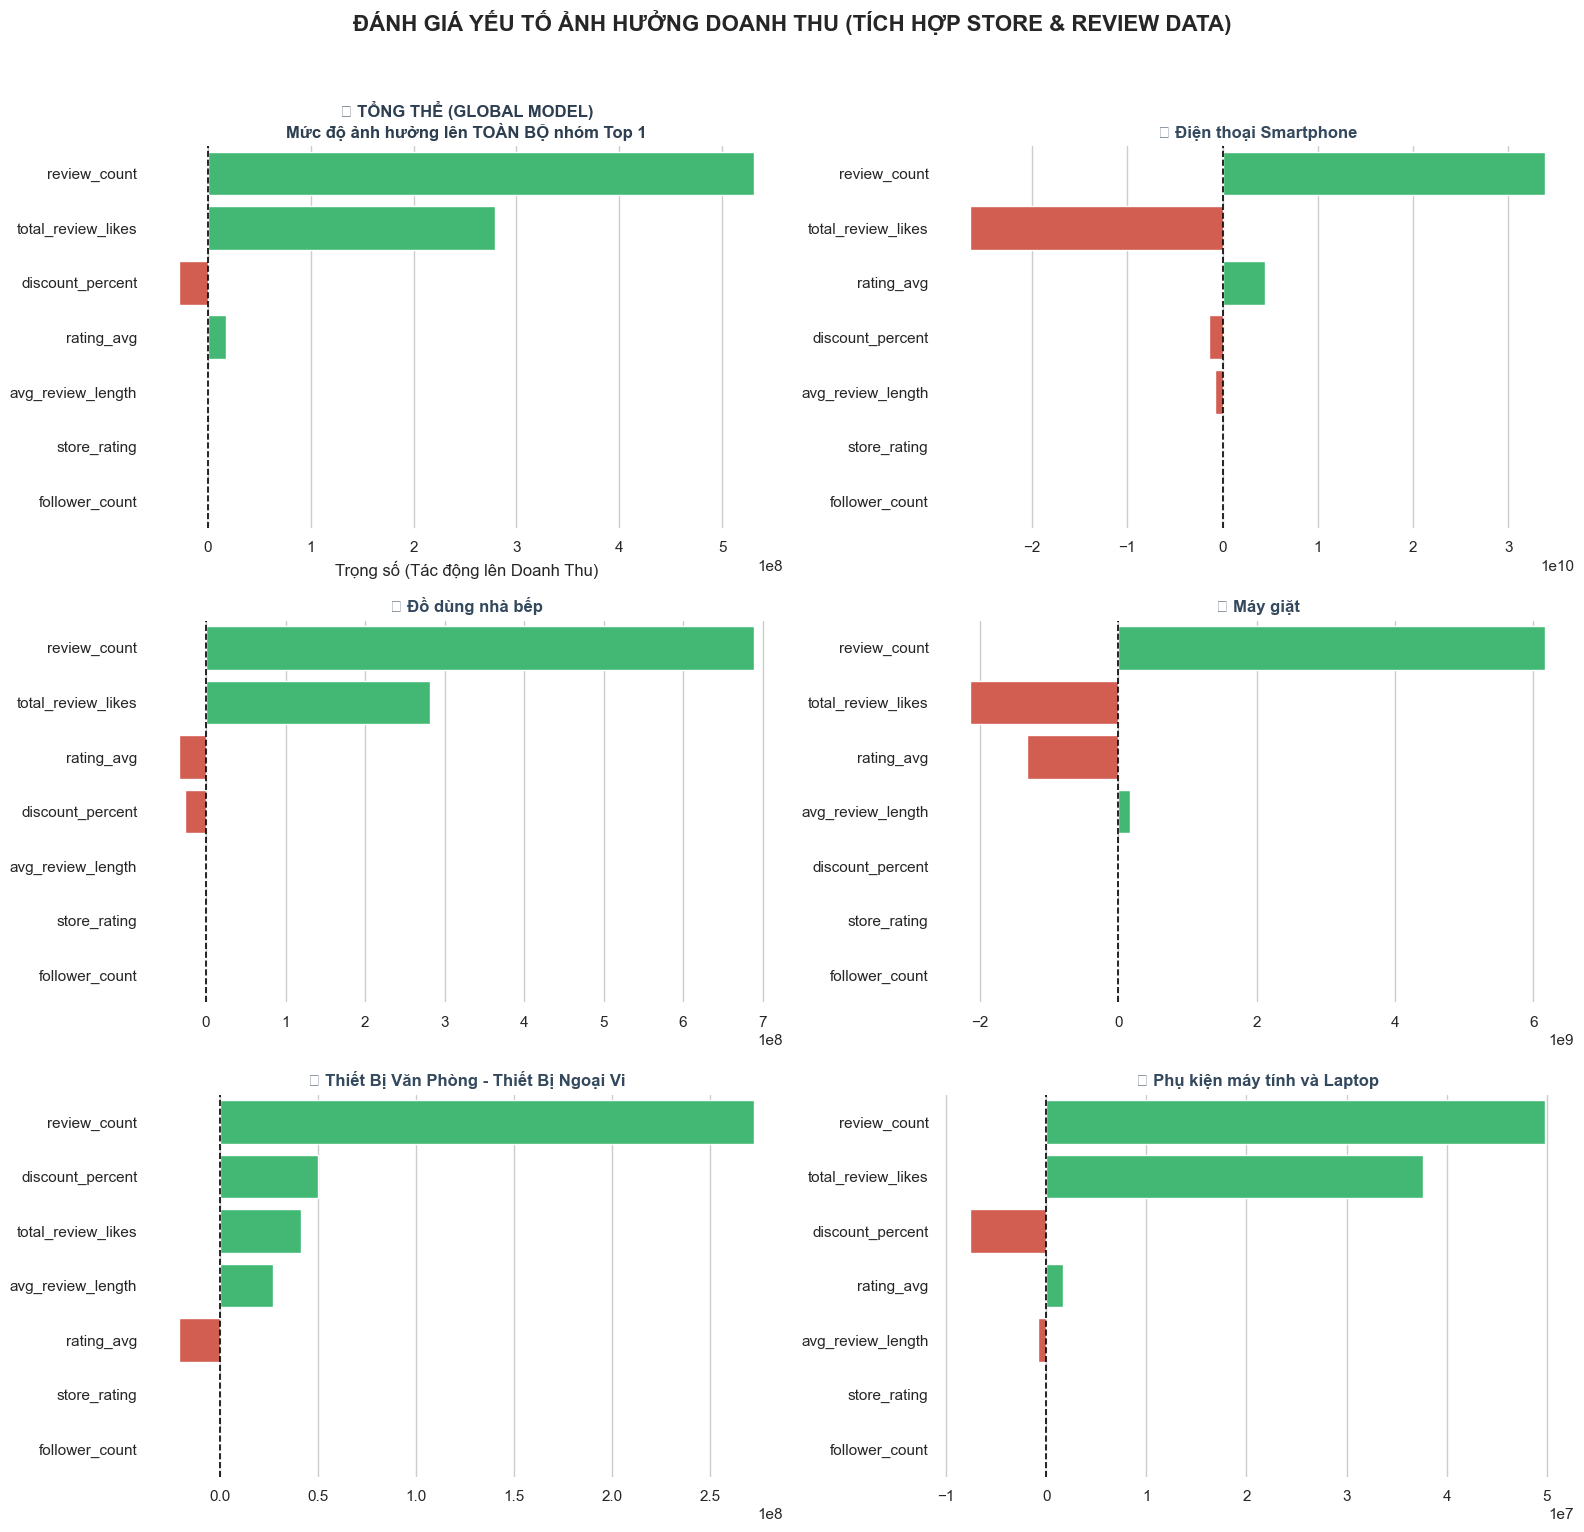

In [ ]:
# ==========================================
# BƯỚC 5: TRỰC QUAN HÓA BẰNG GRID SUBPLOTS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="whitegrid")

num_plots = 1 + len(local_weights_dict)
cols = 2
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

def plot_weights_on_ax(ax, df_w, title, is_global=False):
    colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in df_w['Weight']]
    sns.barplot(data=df_w, x='Weight', y='Attribute', palette=colors, hue='Attribute', legend=False, ax=ax)
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
    
    if is_global:
        ax.set_title(f'🌟 TỔNG THỂ (GLOBAL MODEL)\n{title}', fontsize=12, fontweight='bold', color='#2c3e50')
    else:
        ax.set_title(f'📁 {title}', fontsize=12, fontweight='bold', color='#34495e')
        
    ax.set_xlabel('Trọng số (Tác động lên Doanh Thu)' if is_global else '')
    ax.set_ylabel('')
    sns.despine(ax=ax, left=True, bottom=True)

# Vẽ Global Model
plot_weights_on_ax(axes[0], global_weights, 'Mức độ ảnh hưởng lên TOÀN BỘ nhóm Top 1', is_global=True)

# Vẽ Local Models
plot_idx = 1
for cat_name, df_w in local_weights_dict.items():
    plot_weights_on_ax(axes[plot_idx], df_w, cat_name)
    plot_idx += 1

# Xóa các trục bị dư
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('ĐÁNH GIÁ YẾU TỐ ẢNH HƯỞNG DOANH THU (TÍCH HỢP STORE & REVIEW DATA)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

review_count ảnh hưởng tích cực và trực tiếp nhất
total_review ảnh hưởng tích cực và đóng góp nhiều cho kq trong hầu hết trừ 2 danh mục (smartphone và máy giặt)

nếu khám phá từng cái thì sẽ khám phá cái gì?
- khám phá thử xem tại sao total_review_likes lại gây ảnh hưởng tiêu cực đến 2 nhóm này
- tại sao discounted percent lại gây ảnh hưởng âm ở 1 số nhóm

2.2 Máy giặt

--- KHÁM PHÁ MỐI QUAN HỆ GIỮA GIẢM GIÁ VÀ DOANH THU ---



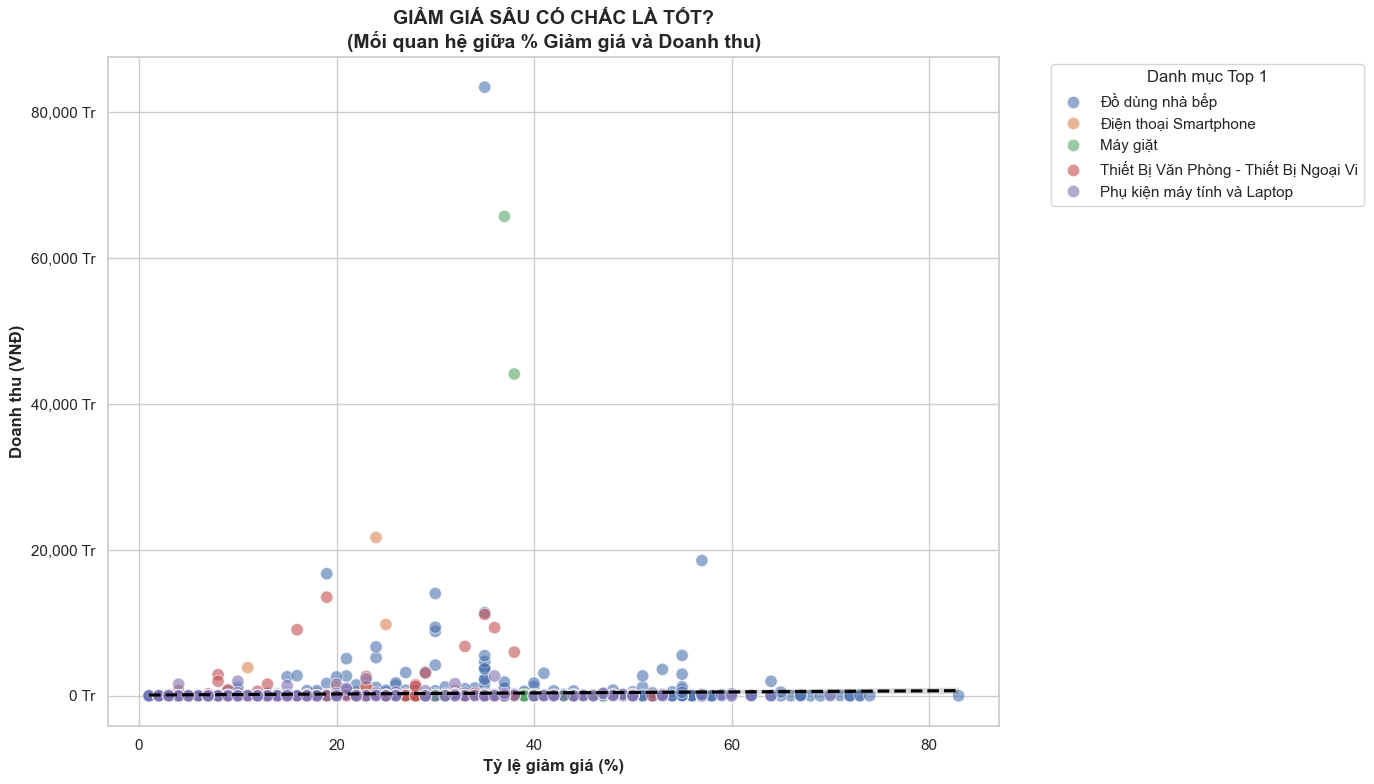

In [ ]:
# --- CODE CHO TO-DO 2.2 ---
print("--- KHÁM PHÁ MỐI QUAN HỆ GIỮA GIẢM GIÁ VÀ DOANH THU ---\n")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Vẽ biểu đồ Scatter (Phân tán) để xem giảm giá bao nhiêu thì bán được nhiều tiền nhất
# Dùng hue để tách màu theo từng Danh mục
sns.scatterplot(
    data=df_top_products[df_top_products['discount_percent'] > 0], # Bỏ qua các SP không giảm giá để nhìn rõ
    x='discount_percent', 
    y='revenue', 
    hue='L2_ancestor',
    alpha=0.6,
    s=80 # Kích thước chấm
)

# Thêm đường xu hướng (Trendline) mờ mờ cho toàn bộ dữ liệu
sns.regplot(
    data=df_top_products[df_top_products['discount_percent'] > 0], 
    x='discount_percent', 
    y='revenue', 
    scatter=False, 
    color='black', 
    line_kws={"linestyle": "--"}
)

plt.title('GIẢM GIÁ SÂU CÓ CHẮC LÀ TỐT?\n(Mối quan hệ giữa % Giảm giá và Doanh thu)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ giảm giá (%)', fontweight='bold')
plt.ylabel('Doanh thu (VNĐ)', fontweight='bold')

# Format trục Y về đơn vị Triệu
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y/1_000_000:,.0f} Tr'))

plt.legend(title='Danh mục Top 1', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis and Conclusion - Question 2

#### Key Observations:

1. 
2. 
3. 

#### Conclusion:


---
## OVERALL CONCLUSION
